# Google severe events exploration
<!-- markdownlint-disable MD013 -->
Using the Colab notebook [here](https://colab.research.google.com/drive/1WbiSF4bvjSLdAEnYaBgw1LrL_Vf_cB9Y#scrollTo=e0PLcJaUdnJg) as a reference.

REST API reference [here](https://developers.google.com/flood-forecasting/rest).

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [40]:
import io
import os

import requests
import geopandas as gpd

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [22]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
BASE_URL = "https://floodforecasting.googleapis.com/v1"

In [23]:
severe_events = []
request = {}

while True:
    res = requests.post(
        f"{BASE_URL}/severeEvents:searchLatestSevereEvents?key={GOOGLE_API_KEY}",
        json=request,
    )
    severe_events_response = res.json()
    if "error" in severe_events_response:
        print(severe_events_response)
        break
    severe_events.extend(severe_events_response.get("severeEvents", []))
    nextPageToken = severe_events_response.get("nextPageToken")
    if not nextPageToken:
        break
    request["pageToken"] = nextPageToken

In [47]:
severe_events[0]

{'eventInterval': {'startTime': '2025-09-10T00:00:00Z',
  'minimumEndTime': '2025-10-10T00:00:00Z'},
 'affectedCountryCodes': ['ML', 'GN'],
 'affectedPopulation': 4444669,
 'areaKm2': 18563.977,
 'gaugeIds': ['hybas_1120705070',
  'hybas_1121919510',
  'hybas_1120689830',
  'hybas_1120759350',
  'hybas_1121900350',
  'hybas_1120753010',
  'hybas_1120737100',
  'hybas_1121893090',
  'hybas_1120761990',
  'hybas_1121890140',
  'hybas_1121905290',
  'hybas_1121895840',
  'hybas_1120768290',
  'hybas_1120679780',
  'hybas_1121935630',
  'hybas_1120762720',
  'hybas_1120788800',
  'hybas_1120767370',
  'hybas_1120744170',
  'hybas_1120689090',
  'hybas_1120727970',
  'hybas_1120778420',
  'hybas_1120727660',
  'hybas_1120795400',
  'hybas_1120801240',
  'hybas_1120707980',
  'hybas_1120770580',
  'hybas_1120667560',
  'hybas_1120700000',
  'hybas_1120787830',
  'hybas_1120783230',
  'hybas_1120684520',
  'hybas_1120710930',
  'hybas_1120773820',
  'hybas_1120789000',
  'hybas_1120731270',
 

In [46]:
len(severe_events[0]["gaugeIds"])

159

In [25]:
if not severe_events:
    print("No severe events found")
else:
    event = severe_events[0]
    serialized_polygon_response = requests.get(
        f"{BASE_URL}/serializedPolygons/{event['eventPolygonId']}?key={GOOGLE_API_KEY}"
    ).json()
    if "error" in serialized_polygon_response:
        print(
            f'Error fetching polygon: {serialized_polygon_response["error"]}'
        )
    else:
        with open(f"temp/event_polygon.kml", "w") as f:
            f.write(serialized_polygon_response["kml"])

In [36]:
kml_text = serialized_polygon_response["kml"]

In [50]:
gdf

,Name,Description,geometry
0,InundationPolygon,,"MULTIPOLYGON (((-11.16659 11.88769, -11.16055 ..."


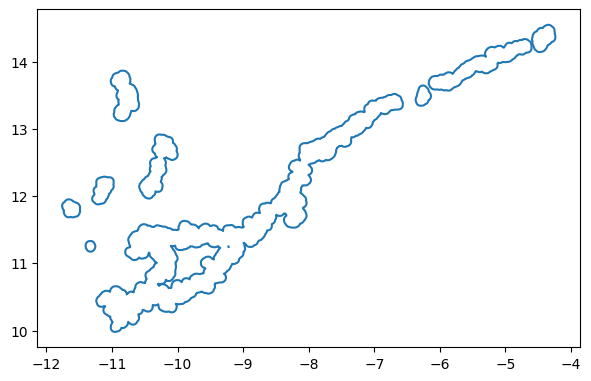

In [48]:
gdf = gpd.read_file(io.BytesIO(kml_text.encode("utf-8")), driver="LIBKML")
ax = gdf.boundary.plot(figsize=(7, 6))

In [28]:
def check_discovery():
    """Fetch and print methods from the discovery document."""
    url = f"https://floodforecasting.googleapis.com/$discovery/rest?version=v1&key={GOOGLE_API_KEY}"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    doc = r.json()

    print("=== Discovery document methods ===")
    # Resources and their methods
    for resource, details in doc.get("resources", {}).items():
        print("Resource:", resource)
        for method_name in details.get("methods", {}):
            print("   -", method_name)

    # Top-level methods
    for method_name in doc.get("methods", {}):
        print("Top-level method:", method_name)

In [29]:
check_discovery()

=== Discovery document methods ===
Resource: gauges
   - get
   - batchGet
   - searchGaugesByArea
   - queryGaugeForecasts
Resource: severeEvents
   - searchLatestSevereEvents
Resource: gaugeModels
   - get
   - batchGet
Resource: floodStatus
   - queryLatestFloodStatusByGaugeIds
   - searchLatestFloodStatusByArea
Resource: serializedPolygons
   - get
